1. Phenotype layer = summary variables these show convergence across environments
2. Biomass-realization layer  = 5000 biomass producing reactions; shows HOW the cell builds biomass (internal gene expression)
3. Metabolic adaptation layer = exchange reactions etc; environment-response layer

**Understanding biomass types**
* protein = translation
* RNA = transcription
* lipid = post-translation
* prosthetic group = complex formation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

plt.style.use("ggplot")

In [ ]:
from pathlib import Path
import sys
import os

ROOT = Path(os.getcwd())

# if notebook is in notebooks/, go up one level
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"

sys.path.append(str(ROOT))

In [3]:
df = pd.read_pickle(DATA/'bm_all_samples.pkl')
# df_filtered = df.loc[(df != 0).any(axis=1)]

In [4]:
df.shape

(3823, 7259)

### Sanity checks

In [5]:
df.isna().sum().sum()

np.int64(0)

In [ ]:
tol = 1e-19
non_flux_cols = ["reaction", "biomass_type"]
flux_cols = [c for c in df.columns if c not in non_flux_cols]

In [7]:
tiny_vals = df[flux_cols].stack()
tiny_vals = tiny_vals[(tiny_vals != 0) & (tiny_vals.abs() <= tol)]

print("Number of tiny values:", len(tiny_vals))

Number of tiny values: 1113


In [ ]:
print(tiny_vals.head())

28  no3_glyc_sample_63   -3.861484e-41
53  glc_sample_334        9.605950e-20
    glyc_sample_29        8.354200e-20
    glyc_sample_325       5.960435e-20
    glyc_sample_443       1.263455e-20
dtype: float64


In [9]:
df_clean = df.copy()

mask = df_clean[flux_cols].abs() <= tol
df_clean.loc[:, flux_cols] = df_clean[flux_cols].mask(mask, 0)

In [10]:
tiny_vals = df_clean[flux_cols].stack()
tiny_vals = tiny_vals[(tiny_vals != 0) & (tiny_vals.abs() <= tol)]

print("Number of tiny values in clean df:", len(tiny_vals))

Number of tiny values in clean df: 0


# Overview of  reaction activity

In [11]:
df_plot = df_clean[~df_clean["biomass_type"].isin(["mu", "env"])]

active_counts = (df_plot[flux_cols] != 0).sum(axis=1)

/triumvirate/apps/.scratch/celinaha/ipykernel_1185710/1371928336.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


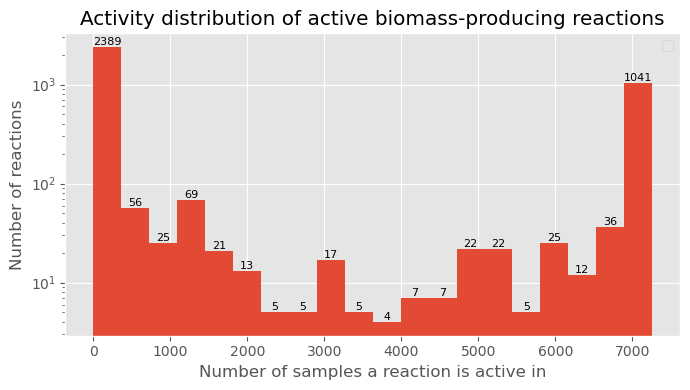

In [12]:
plt.figure(figsize=(7,4))

counts, bins, patches = plt.hist(active_counts, bins=20)

# Add counts on top of each bin
for count, left, right in zip(counts, bins[:-1], bins[1:]):
    if count > 0:
        plt.text(
            (left + right) / 2,   # bin center
            count,                # height
            int(count),
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.yscale("log")
plt.xlabel("Number of samples a reaction is active in")
plt.ylabel("Number of reactions")
plt.title("Activity distribution of active biomass-producing reactions")
plt.legend()

plt.tight_layout()
plt.show()

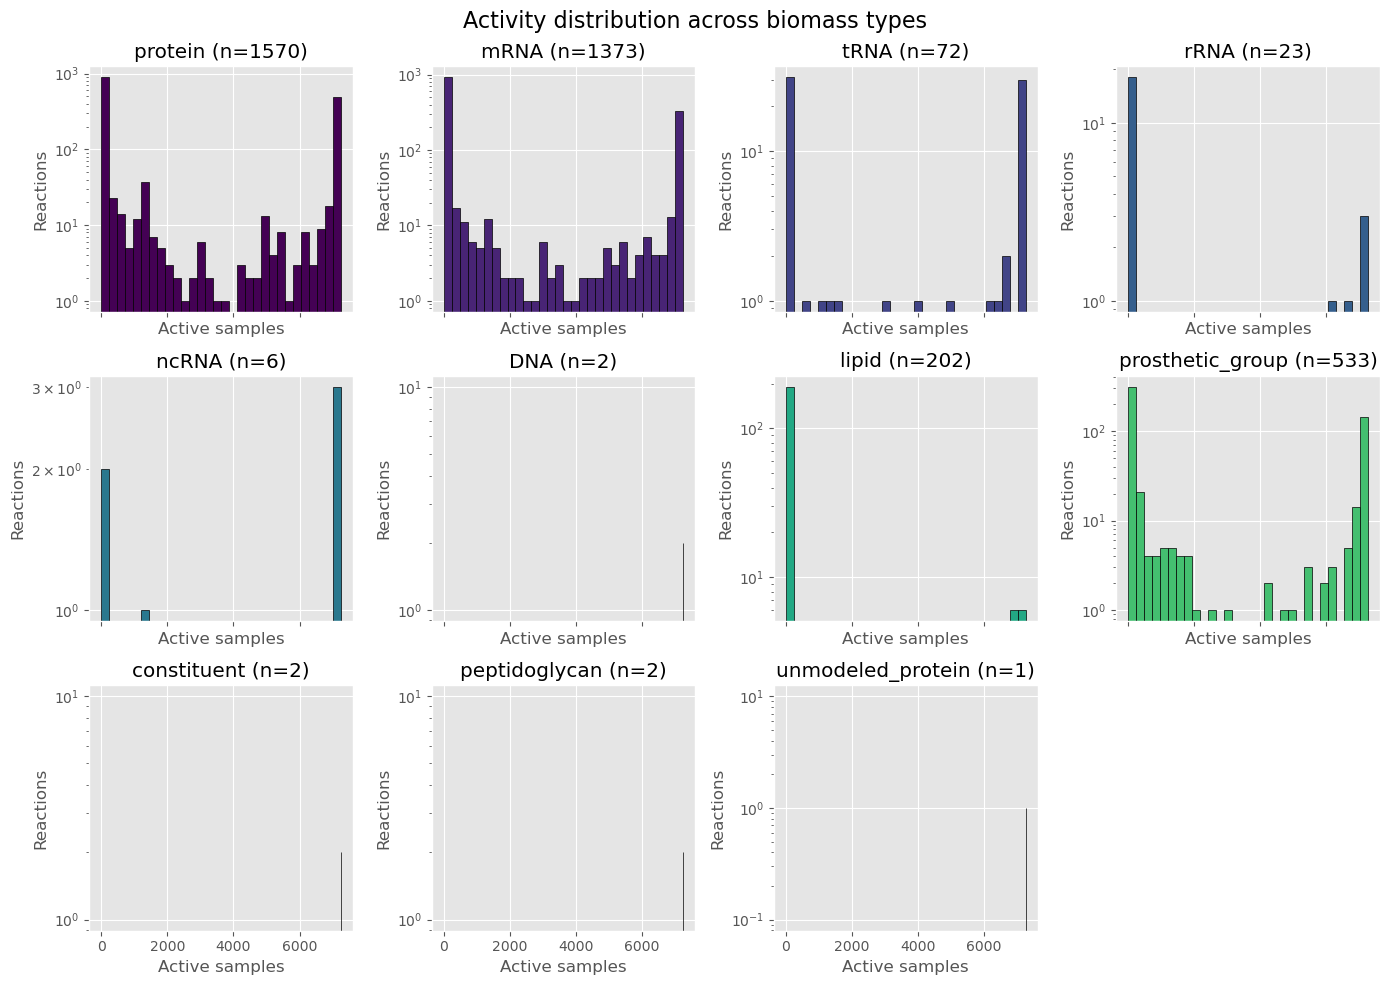

In [13]:
import math

biomass_types = df_plot["biomass_type"].unique()
cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, len(biomass_types)))

# Layout: 3 rows × 4 columns (fits 11 nicely)
ncols = 4
nrows = math.ceil(len(biomass_types) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 10), sharex=True)
axes = axes.flatten()

threshold = 15

for ax, btype, color in zip(axes, biomass_types, colors):
    sub_df = df_plot[df_plot["biomass_type"] == btype]

    reaction_data = sub_df.drop(columns=["biomass_type"])

    active_counts = (reaction_data != 0).sum(axis=1)

    ax.hist(active_counts, bins=30, color=color, edgecolor="black")
    # ax.axvline(threshold, linestyle="--", color="red", linewidth=1)

    ax.set_yscale("log")  
    ax.set_title(f"{btype} (n={len(active_counts)})")
    ax.set_xlabel("Active samples")
    ax.set_ylabel("Reactions")

# Remove empty subplot(s)
for ax in axes[len(biomass_types):]:
    fig.delaxes(ax)

fig.suptitle("Activity distribution across biomass types", fontsize=16)
plt.tight_layout()
plt.show()

* det er to constituents som er aktiv i alle

## Removing reactions with low activity (< 50 counts) and constant activity

In [14]:
df_no_env = df_clean.loc[df_clean["biomass_type"] != "env"]
mu_row = df_no_env.loc[df_no_env["biomass_type"] == "mu"]
df_no_env_no_mu = df_no_env.loc[df_no_env["biomass_type"] != "mu"]

active_counts = (df_no_env_no_mu != 0).sum(axis=1)

max_samples = df.shape[1]

df_filtered = df_no_env_no_mu.loc[
    (active_counts >= 50) &
    (active_counts < 0.99 * max_samples)
]

df_filtered = pd.concat([df_filtered, mu_row])

In [ ]:
non_flux_cols = ["reaction", "biomass_type"]
flux_cols = [c for c in df_filtered.columns if c not in non_flux_cols]

In [16]:
tiny_mask = (df_filtered[flux_cols].abs() > 0) & (df_filtered[flux_cols].abs() <= tol)

# Columns (samples) that contain tiny values
tiny_cols = tiny_mask.columns[tiny_mask.any(axis=0)]
tiny_cols

Index([], dtype='str')

**Which reactions vary most:**

In [17]:
# variance = df_filtered.select_dtypes(include="number").var(axis=1)

df_no_mu = df_filtered[df_filtered["biomass_type"] != "mu"].copy()

non_flux_cols = ["reaction", "biomass_type"]
flux_cols = [c for c in df_no_mu.columns if c not in non_flux_cols]

variance = df_no_mu[flux_cols].var(axis=1)
top_var = variance.sort_values(ascending=False).head(31)

In [18]:
df_filtered.loc[top_var.index]

,reaction,biomass_type,glc_sample_0,glc_sample_1,glc_sample_2,glc_sample_3,glc_sample_4,glc_sample_5,glc_sample_6,glc_sample_7,...,no3_glyc_sample_586,no3_glyc_sample_587,no3_glyc_sample_588,no3_glyc_sample_589,no3_glyc_sample_590,no3_glyc_sample_591,no3_glyc_sample_592,no3_glyc_sample_593,no3_glyc_sample_594,no3_glyc_sample_595
1587,b1677_lipid_modification_pg120_p_pe160,lipid,3.482817e-04,1.383005e-03,7.416127e-04,4.698607e-04,9.505117e-05,0.001697,4.278473e-04,7.885426e-04,...,2.884158e-04,7.130677e-04,9.048269e-04,0.002142,1.041580e-03,7.269118e-04,2.133268e-04,5.298270e-04,5.450012e-04,0.001580
1593,b1677_lipid_modification_pg181_p_pe160,lipid,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
1599,b1677_lipid_modification_pg180_p_pe160,lipid,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
3002,translation_b3737,protein,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,3.677018e-05,...,0.000000e+00,6.021769e-08,8.844294e-08,0.000190,1.107897e-07,0.000000e+00,0.000000e+00,3.857697e-08,3.992611e-08,0.000083
2296,translation_b1778,protein,0.000000e+00,1.470033e-04,2.566813e-04,1.221787e-04,2.671952e-05,0.000000,4.209395e-06,0.000000e+00,...,1.122704e-04,1.124213e-04,1.332710e-04,0.000173,1.874353e-04,2.786239e-04,9.148080e-05,4.672645e-05,7.968990e-05,0.000391
3251,translation_b4395,protein,7.674010e-05,2.573203e-04,8.658590e-05,8.483625e-05,3.870154e-06,0.000274,7.496322e-05,1.181104e-03,...,8.738385e-08,8.780572e-06,1.803344e-05,0.000068,1.326441e-05,5.247568e-07,4.792093e-08,1.333274e-05,6.671703e-06,0.000002
3090,translation_b3945,protein,4.308966e-05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000057,2.909072e-05,0.000000e+00,...,9.872201e-06,3.560533e-05,4.693001e-05,0.000099,8.646510e-05,5.895991e-05,9.440594e-06,3.294734e-07,1.779799e-05,0.000164
2695,translation_b2938,protein,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
3091,translation_b3946,protein,1.153701e-04,2.648558e-04,8.897447e-05,8.661435e-05,0.000000e+00,0.000333,1.715049e-04,0.000000e+00,...,8.520939e-06,3.073183e-05,4.050645e-05,0.000085,7.463015e-05,5.088974e-05,8.148408e-06,2.843765e-07,1.536188e-05,0.000141
2311,translation_b1850,protein,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.418865e-06,0.000000,0.000000e+00,0.000000e+00,...,1.154434e-05,4.144349e-05,5.440136e-05,0.000110,1.008154e-04,6.889975e-05,1.109752e-05,0.000000e+00,2.065972e-05,0.000189


In [ ]:
df_filtered["variance"] = variance

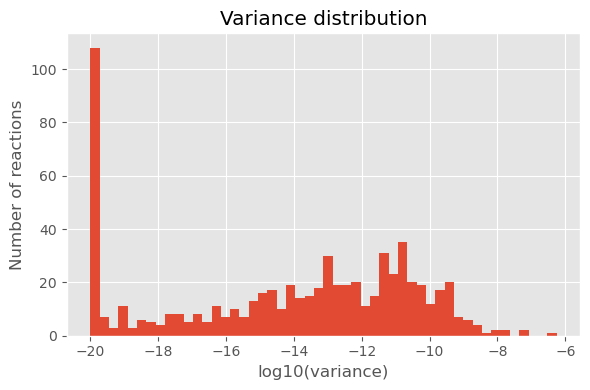

In [20]:
plt.figure(figsize=(6,4))
plt.hist(np.log10(variance + 1e-20), bins=50)
plt.xlabel("log10(variance)")
plt.ylabel("Number of reactions")
plt.title("Variance distribution")
plt.tight_layout()
plt.show()

In [ ]:
variance.describe()

count    6.540000e+02
mean     1.134832e-09
std      2.185563e-08
min      2.603624e-37
25%      7.887436e-18
50%      4.642100e-14
75%      7.574629e-12
max      5.544535e-07
dtype: float64

In [22]:
df_filtered.sort_values("variance", ascending=False).head(20)[
    ["reaction", "biomass_type", "variance"]
]

,reaction,biomass_type,variance
1587,b1677_lipid_modification_pg120_p_pe160,lipid,5.544535e-07
1593,b1677_lipid_modification_pg181_p_pe160,lipid,4.910928e-08
1599,b1677_lipid_modification_pg180_p_pe160,lipid,4.738890e-08
3002,translation_b3737,protein,1.598051e-08
2296,translation_b1778,protein,1.497114e-08
3251,translation_b4395,protein,9.579327e-09
3090,translation_b3945,protein,6.940559e-09
2695,translation_b2938,protein,3.879380e-09
3091,translation_b3946,protein,3.067745e-09
2311,translation_b1850,protein,2.942116e-09


**components driving variance**

In [23]:
high_var = df_filtered[df_filtered["variance"] >= variance.quantile(0.9)]
high_var["biomass_type"].value_counts()

biomass_type
protein             56
prosthetic_group     7
lipid                3
Name: count, dtype: int64

**distribution per biomass type**

In [24]:
# df_plot = df_filtered[df_filtered["biomass_type"] != "mu"].copy()
df_plot = df_filtered.drop(columns=["reaction", "variance"], errors="ignore")
df_plot = df_plot[:-1]

df_long = df_plot.melt(
    id_vars="biomass_type",
    var_name="sample",
    value_name="flux"
)

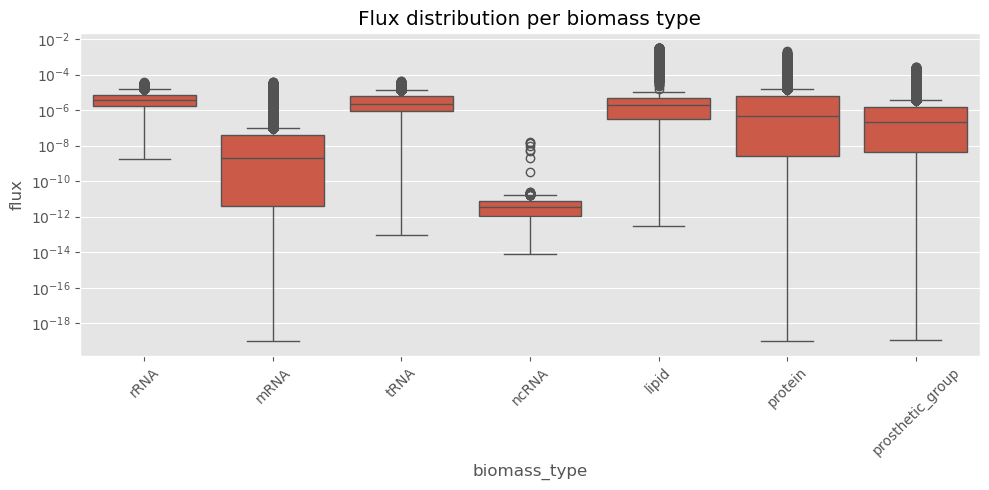

In [25]:
df_long = df_long[df_long["flux"] > 0]

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df_long,
    x="biomass_type",
    y="flux"
)

plt.xticks(rotation=45)
plt.yscale('log')
plt.title("Flux distribution per biomass type")
plt.tight_layout()
plt.show()

In [26]:
df_filtered['biomass_type'].value_counts()

biomass_type
protein             300
mRNA                197
prosthetic_group    123
lipid                18
tRNA                 13
rRNA                  2
ncRNA                 1
mu                    1
Name: count, dtype: int64

In [27]:
df_filtered[df_filtered['biomass_type']=='ncRNA']

,reaction,biomass_type,glc_sample_0,glc_sample_1,glc_sample_2,glc_sample_3,glc_sample_4,glc_sample_5,glc_sample_6,glc_sample_7,...,no3_glyc_sample_587,no3_glyc_sample_588,no3_glyc_sample_589,no3_glyc_sample_590,no3_glyc_sample_591,no3_glyc_sample_592,no3_glyc_sample_593,no3_glyc_sample_594,no3_glyc_sample_595,variance
1478,transcription_TU482_with_TERM161_from_RpoD_mon...,ncRNA,5.523405e-14,0.0,0.0,0.0,0.0,8.431024e-13,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.116937e-19


**Which reactions are less correlated with growth**

In [28]:
df_corr = df_filtered.set_index("reaction")
mu = df_corr.loc["biomass_dilution"]

reaction_data = df_corr.drop(index="biomass_dilution")
reaction_data = reaction_data.drop(columns=["biomass_type"], errors="ignore")
corr = reaction_data.T.corrwith(mu, method="spearman")

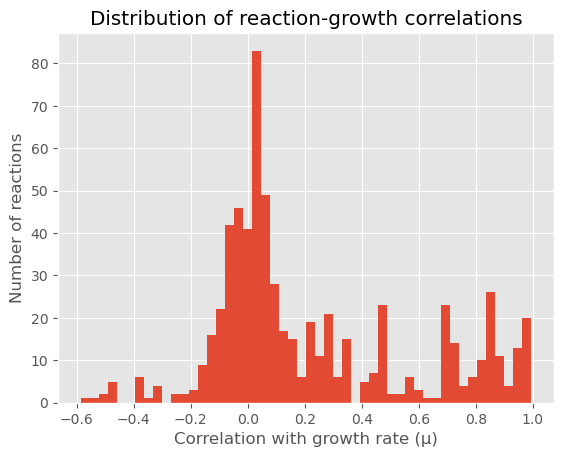

In [29]:
plt.hist(corr, bins=50)
plt.xlabel("Correlation with growth rate (μ)")
plt.ylabel("Number of reactions")
plt.title("Distribution of reaction-growth correlations")
plt.show()

In [ ]:
low_corr_mask = corr.abs() < 0.5
low_corr = reaction_data.loc[low_corr_mask]

In [ ]:
low_corr_T = low_corr.T

In [ ]:
low_corr_T["source"] = low_corr_T.index.str.split("_sample_").str[0]

In [ ]:
low_corr_T['source'].value_counts()

source
lcts        786
glc         703
no3_glc     689
nh4_glc     685
arg_glc     667
arg_glyc    653
no3_glyc    596
arg_ac      583
glyc        580
succ        509
ac          482
nh4_ac      291
no3_ac       33
variance      1
Name: count, dtype: int64

In [34]:
low_corr_T.groupby("source").mean()

reaction,transcription_TU0_13350_from_RpoD_mono,transcription_TU00158_from_RpoD_mono,transcription_TU0_1002_from_RpoD_mono,transcription_TU0_12820_from_RpoD_mono,transcription_TU0_14254_with_AROH_TERMINATOR_from_RpoD_mono,transcription_TU00160_with_TERM66_from_RpoD_mono,transcription_TU0_14052_from_RpoD_mono,transcription_TU441_from_RpoD_mono,transcription_TU0_1004_from_RPOS_MONOMER,transcription_TU0_8472_from_RpoD_mono,...,formation_ISOCITHASE-CPLX_mod_mn2,formation_ISOCITHASE-CPLX_mod_mg2,formation_FLAVONADPREDUCT-MONOMER_mod_fad,formation_IMIDHISTID-CPLX_mod_mn2,formation_NAPAB-CPLX_NAPC-MONOMER_mod_bmocogdp,formation_NAP-CPLX_mod_bmocogdp,formation_PYRUVFORMLY-MONOMER_EG11784-MONOMER_mod_glycyl,formation_2OXOGLUTARATEDEH-CPLX_mod_mg2_mod_lipoalt,formation_PYRUVATEDEH-CPLX_mod_mg2_mod_fad_mod_thmpp_mod_lipoalt,formation_GCVMULTI-CPLX_mod_lipoalt
source,,,,,,,,,,,,,,,,,,,,,
ac,0.000000e+00,5.737743e-07,0.000000e+00,6.300229e-12,2.417069e-11,0.000000e+00,6.489886e-09,1.765856e-10,0.000000e+00,1.750212e-08,...,4.471093e-08,3.862384e-07,6.921513e-06,1.056133e-07,0.000000e+00,0.000000e+00,3.497385e-09,4.224035e-07,0.000000e+00,3.376813e-09
arg_ac,3.719661e-15,2.387196e-07,2.436152e-08,3.616546e-12,0.000000e+00,1.803533e-08,6.012146e-08,0.000000e+00,8.326865e-09,0.000000e+00,...,3.101901e-08,2.314378e-07,3.888947e-07,1.245296e-07,0.000000e+00,0.000000e+00,6.316666e-11,2.489469e-07,1.046708e-07,1.404754e-09
arg_glc,6.456600e-16,2.592849e-07,4.485904e-09,3.101373e-14,2.504563e-09,0.000000e+00,1.025833e-07,0.000000e+00,2.348772e-08,0.000000e+00,...,8.308297e-09,5.100328e-07,0.000000e+00,2.360700e-08,0.000000e+00,0.000000e+00,1.237525e-12,3.768107e-07,4.378160e-07,0.000000e+00
arg_glyc,7.715188e-16,3.239345e-07,5.900420e-09,4.242229e-14,1.843892e-09,0.000000e+00,9.079192e-08,0.000000e+00,2.015586e-08,0.000000e+00,...,1.572725e-09,4.244118e-07,1.018278e-06,8.621482e-09,0.000000e+00,0.000000e+00,2.337171e-06,3.084771e-07,3.511200e-07,0.000000e+00
glc,0.000000e+00,3.188606e-07,0.000000e+00,3.582404e-12,6.313229e-12,0.000000e+00,6.134558e-09,1.051771e-10,0.000000e+00,2.972235e-08,...,3.539108e-09,2.715953e-07,2.093345e-16,7.561993e-08,0.000000e+00,0.000000e+00,5.950723e-07,2.583345e-07,3.359475e-07,6.514927e-10
glyc,0.000000e+00,6.175246e-07,0.000000e+00,2.820267e-12,8.190254e-12,0.000000e+00,4.228681e-09,5.374064e-11,0.000000e+00,2.494464e-08,...,2.420452e-09,1.686348e-07,1.002314e-06,7.892953e-08,0.000000e+00,0.000000e+00,9.117966e-07,1.573724e-07,2.296553e-07,1.013037e-09
lcts,0.000000e+00,2.194822e-07,0.000000e+00,7.858497e-13,1.512945e-12,0.000000e+00,2.034208e-09,2.270846e-11,0.000000e+00,2.680570e-08,...,6.432795e-10,3.433737e-07,0.000000e+00,1.613659e-08,0.000000e+00,0.000000e+00,2.092669e-07,3.291832e-07,4.092840e-07,2.590860e-10
nh4_ac,5.561232e-21,7.064881e-07,0.000000e+00,6.641228e-12,0.000000e+00,0.000000e+00,0.000000e+00,6.686544e-13,0.000000e+00,1.773534e-08,...,1.095281e-07,4.289228e-07,9.141185e-06,1.482307e-07,0.000000e+00,0.000000e+00,5.600494e-11,5.296711e-07,0.000000e+00,1.008777e-09
nh4_glc,3.585284e-20,7.218815e-07,0.000000e+00,1.431453e-14,0.000000e+00,0.000000e+00,6.068694e-09,6.512141e-15,0.000000e+00,2.638050e-08,...,2.530793e-08,2.421256e-07,0.000000e+00,9.456538e-08,0.000000e+00,0.000000e+00,2.406289e-09,2.528064e-07,3.441857e-07,2.492863e-10


## Combining variance and growth corr analyses:

In [ ]:
df_no_mu["corr_with_mu"] = corr.values
corr_list = df_no_mu["corr_with_mu"].tolist()
corr_list = corr_list + [1.0]

In [ ]:
df_filtered["corr_with_mu"] = corr_list

In [ ]:
interesting = df_filtered[
    (df_filtered["variance"] >= variance.quantile(0.9)) &
    (df_filtered["corr_with_mu"].abs() < 0.5)
]

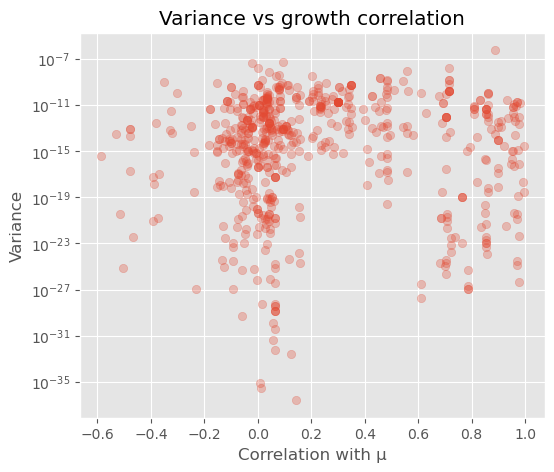

In [38]:
plt.figure(figsize=(6,5))
plt.scatter(df_filtered["corr_with_mu"], df_filtered["variance"], alpha=0.3)
plt.xlabel("Correlation with μ")
# plt.xscale('log')
plt.yscale('log')
plt.ylabel("Variance")
plt.title("Variance vs growth correlation")
plt.show()

**Looking at absolute max and min values of each component, excluding the summary variables**

In [39]:
non_flux_cols = ["reaction", "biomass_type"]
df_clean2 = df_clean[~df_clean["reaction"].str.contains("biomass_to_biomass")].copy()
flux_cols = [c for c in df_clean2.columns if c not in non_flux_cols]

df_long = df_clean2.melt(
    id_vars=["reaction", "biomass_type"],
    value_vars=flux_cols,
    var_name="sample",
    value_name="flux"
)

In [40]:
# df_long_nonzero = df_long[df_long["flux"] != 0]
df_long["abs_flux"] = df_long["flux"].abs()

df_long_nonzero = df_long[df_long["abs_flux"] > 0]

In [41]:
summary = df_long_nonzero.groupby("biomass_type")["abs_flux"].agg(["min", "max"])
summary["log10_min"] = np.log10(summary["min"])
summary["log10_max"] = np.log10(summary["max"])
summary["log10_range"] = summary["log10_max"] - summary["log10_min"]

In [42]:
summary

,min,max,log10_min,log10_max,log10_range
biomass_type,,,,,
DNA,1.001575e-04,0.077269,-3.999316,-1.111994,2.887323
constituent,5.199909e-04,0.875010,-3.284004,-0.057987,3.226017
env,1.374606e-19,300.854554,-18.861822,2.478357,21.340178
lipid,3.001899e-13,15.911937,-12.522604,1.201723,13.724327
mRNA,1.004767e-19,0.000053,-18.997934,-4.273067,14.724867
mu,5.199909e-04,0.875010,-3.284004,-0.057987,3.226017
ncRNA,4.492691e-16,0.000006,-15.347493,-5.232117,10.115376
peptidoglycan,5.199909e-04,0.875010,-3.284004,-0.057987,3.226017
prosthetic_group,1.007748e-19,0.000256,-18.996648,-3.592525,15.404123


### Inspecting interesting reactions

In [ ]:
interesting_rxns = interesting[['reaction', 'biomass_type']]

In [44]:
# Keep only sample columns
meta_cols = ["reaction", "biomass_type"]
sample_cols = [c for c in interesting.columns if c not in meta_cols]

# Extract source label from sample names
sources = pd.Series(sample_cols, index=sample_cols).str.split("_sample_").str[0]

# Count activity (nonzero flux) per reaction, per source
activity_per_source = pd.DataFrame(index=interesting.index)

for source in sources.unique():
    cols = sources[sources == source].index
    activity_per_source[source] = (interesting[cols] != 0).sum(axis=1)

# Optional: add identifiers back
activity_per_source = pd.concat(
    [interesting[["reaction", "biomass_type"]], activity_per_source],
    axis=1
)

# activity_per_source.head()

In [ ]:
activity_per_source.drop(columns=['variance', 'corr_with_mu'], inplace=True)

In [ ]:
activity_per_source['variance']=interesting['variance']
activity_per_source['corr_with_mu']=interesting['corr_with_mu']

In [ ]:
# activity_per_source.to_excel(DATA/'interesting_bm_rxns.xlsx')

**PCA test....**

In [ ]:
source_counts = low_corr_T["source"].value_counts()

In [49]:
activity_fraction = activity_per_source.drop(columns=['variance', 'corr_with_mu']).copy()

for col in source_counts.index:
    if col in activity_fraction.columns:
        activity_fraction[col] = activity_fraction[col] / source_counts[col]

In [50]:
# 1. Set reaction as index in both dataframes
interesting_idx = interesting.drop(columns=['variance', 'corr_with_mu']).set_index("reaction")
activity_idx = activity_fraction.set_index("reaction")

# 2. Keep only sample columns from interesting
meta_cols = ["biomass_type"]
sample_cols = [c for c in interesting_idx.columns if c not in meta_cols]

# 3. Extract source/environment for each sample column
sample_sources = pd.Series(sample_cols, index=sample_cols).str.split("_sample_").str[0]

# 4. Convert to binary activity (THIS IS THE NEW STEP)
activity_binary = (interesting_idx[sample_cols] != 0).astype(int)

# 5. Make weighted copy (start from binary, not original flux)
weighted = activity_binary.copy()

# 6. Multiply by environment-specific activity fraction
for sample in sample_cols:
    source = sample_sources[sample]
    weighted[sample] = activity_binary[sample] * activity_idx[source]

# 7. Add metadata back
weighted["biomass_type"] = interesting_idx["biomass_type"]

# 8. Reset index if needed
weighted = weighted.reset_index()

/triumvirate/apps/.scratch/celinaha/ipykernel_1185710/3391501621.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  weighted["biomass_type"] = interesting_idx["biomass_type"]
/triumvirate/apps/.scratch/celinaha/ipykernel_1185710/3391501621.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  weighted = weighted.reset_index()


In [51]:
sample = "glc_sample_0"
source = sample.split("_sample_")[0]

check = pd.DataFrame({
    "original": interesting_idx[sample],
    "weight": activity_idx[source],
    "weighted": weighted.set_index("reaction")[sample]
})

check.head()

,original,weight,weighted
reaction,,,
b1677_lipid_modification_pg181_p_pe160,0.000000e+00,0.000000,0.000000
b1677_lipid_modification_pg180_p_pe160,0.000000e+00,0.012802,0.000000
translation_b0123,0.000000e+00,0.731152,0.000000
translation_b0720,3.558155e-08,1.000000,1.000000
translation_b0721,4.869491e-14,0.806543,0.806543


In [52]:
weighted_idx = weighted.set_index("reaction")
X = weighted_idx[sample_cols].T
# X["source"] = X.index.str.split("_sample_").str[0]
X["source"] = X.index.str.split("_sample_").str[0]

In [53]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

features = X.drop(columns="source")

# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(features)

pca = PCA(n_components=10)
scores = pca.fit_transform(features)

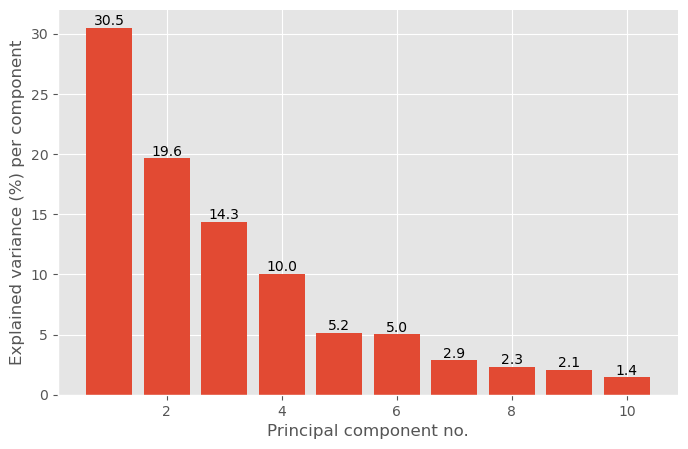

In [54]:
variance = pca.explained_variance_ratio_
components = 1 + np.arange(len(variance))

plt.figure(figsize=(8,5))
bar = plt.bar(components, variance*100)
plt.bar_label(bar, fmt="{:.1f}")
plt.xlabel('Principal component no.')
plt.ylabel('Explained variance (%) per component')
sns.despine()

In [55]:
df_pca = pd.DataFrame({
    "PC1": scores[:, 0],
    "PC2": scores[:, 1],
    "PC3": scores[:, 2],
    "PC4": scores[:, 3],
    "source": X["source"].values
})

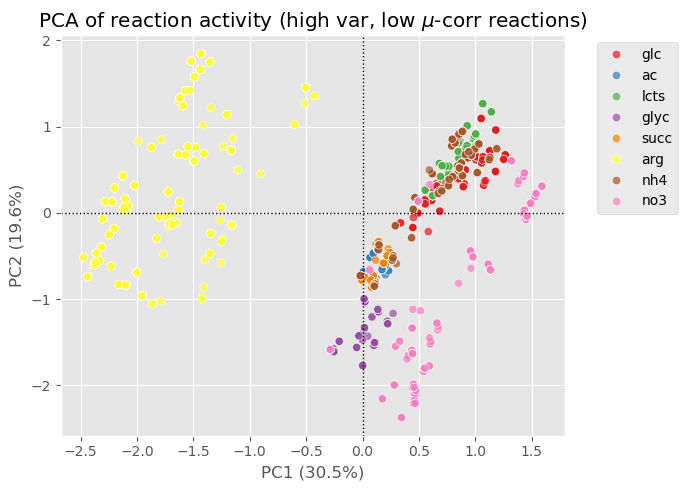

In [56]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="source",
    palette="Set1",
    alpha=0.7
)

plt.axhline(y=0, ls=":", c="k", lw=1)
plt.axvline(x=0, ls=":", c="k", lw=1)
plt.title(r"PCA of reaction activity (high var, low $\mu$-corr reactions)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [64]:
loadings = pd.DataFrame(
    pca.components_.T[:, :4],
    index=features.columns,
    columns=["PC1", "PC2","PC3", "PC4"]
)

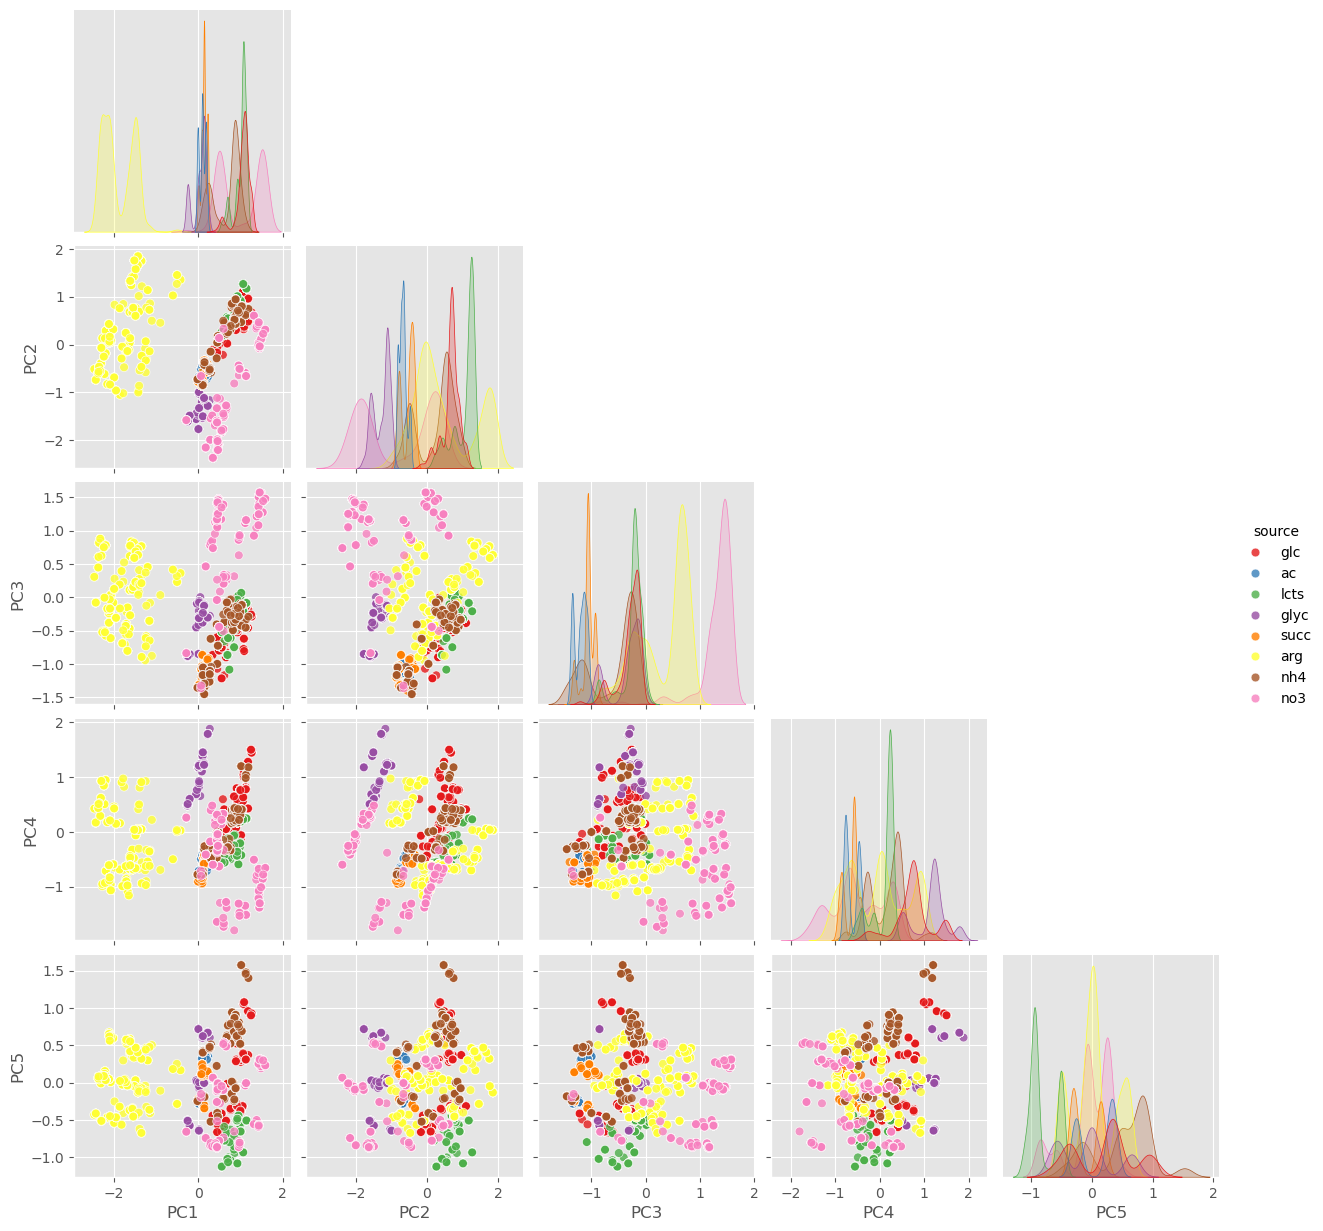

In [64]:
scores_df = pd.DataFrame(
    scores[:, :5],
    columns=[f"PC{i}" for i in range(1, 6)]
)

# Add metadata for coloring
scores_df["source"] = X["source"].values

sns.pairplot(
    scores_df,
    hue="source",
    palette="Set1",
    corner=True,
    plot_kws={"s": 40, "alpha": 0.8}
)

plt.show()

In [65]:
import plotly.express as px
palette = sns.color_palette("Set1", n_colors=df_pca["source"].nunique()).as_hex()
# 3. Create the interactive 3D scatter plot
fig = px.scatter_3d(
    df_pca, 
    x='PC1', 
    y='PC2', 
    z='PC3',
    opacity=0.6,
    color_discrete_sequence=palette,
    color = X['source'],
    # title='Interactive 3D PCA of Biomass Components',
    labels={
        'PC1': f'PC1 ({pca.explained_variance_ratio_[0]:.1%})',
        'PC2': f'PC2 ({pca.explained_variance_ratio_[1]:.1%})',
        'PC3': f'PC3 ({pca.explained_variance_ratio_[2]:.1%})'
    }
)

# This makes the dots a bit smaller and cleaner
fig.update_traces(marker=dict(size=4))

fig.show()

In [65]:
loadings.sort_values(by='PC2', ascending=False)

,PC1,PC2,PC3,PC4
reaction,,,,
translation_b2416,0.156293,0.355497,0.167682,-0.032685
translation_b2943,0.179985,0.332096,0.133757,0.075475
translation_b2388,0.172007,0.319116,0.138444,0.072804
translation_b1101,0.223317,0.225779,0.113041,-0.017071
translation_b1602,0.091457,0.171820,-0.054244,0.264254
translation_b1603,0.091457,0.171820,-0.054244,0.264254
translation_b0767,0.111613,0.169619,0.337102,0.251517
translation_b0123,0.087369,0.146285,0.060845,0.203653
translation_b1850,0.015396,0.136820,0.277107,0.016525


## PCA by environment:

In [58]:
# nitrogen_sources = ["nh4", "no3", "arg"]
nitrogen_sources = ["nh4_glc", "nh4_ac", 
                    "no3_glc", "no3_ac", "no3_glyc", 
                    "arg_glc", "arg_ac", "arg_glyc"]



In [59]:
X["source_type"] = np.where(
    X["source"].isin(nitrogen_sources),
    "n",   # if in nitrogen_sources
    "c"    # otherwise
)

In [60]:
carbon = X[X['source_type']=='c']
nitrogen=X[X['source_type']=='n']

In [61]:
features_c = carbon.drop(columns=["source", "source_type"])
features_n = nitrogen.drop(columns=["source", "source_type"])

# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(features)

pca_c = PCA(n_components=10)
scores_c = pca_c.fit_transform(features_c)

pca_n = PCA(n_components=10)
scores_n = pca_n.fit_transform(features_n)

In [62]:
df_pca_c = pd.DataFrame({
    "PC1": scores_c[:, 0],
    "PC2": scores_c[:, 1],
    "source": carbon["source"].values
})


df_pca_n = pd.DataFrame({
    "PC1": scores_n[:, 0],
    "PC2": scores_n[:, 1],
    "source": nitrogen["source"].values
})

In [63]:
loadings_c = pd.DataFrame(
    pca_c.components_.T[:, :3],
    index=features_c.columns,
    columns=["PC1", "PC2", "PC3"]
)

loadings_n = pd.DataFrame(
    pca_n.components_.T[:, :3],
    index=features_n.columns,
    columns=["PC1", "PC2", "PC3"]
)

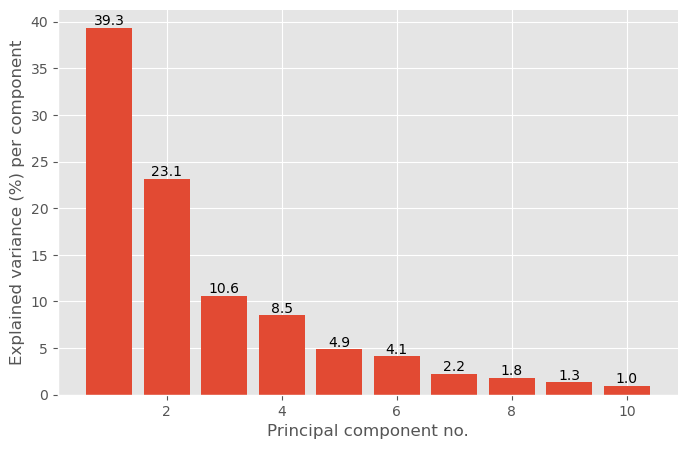

In [72]:
variance_c = pca_c.explained_variance_ratio_
components_c = 1 + np.arange(len(variance_c))

plt.figure(figsize=(8,5))
bar = plt.bar(components_c, variance_c*100)
plt.bar_label(bar, fmt="{:.1f}")
plt.xlabel('Principal component no.')
plt.ylabel('Explained variance (%) per component')
sns.despine()

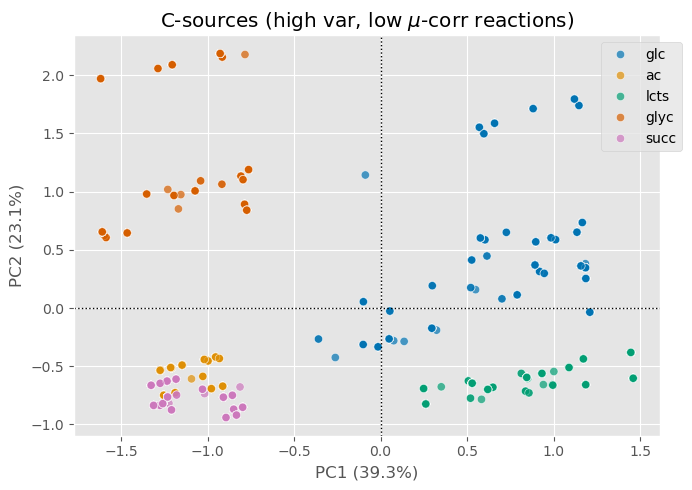

In [127]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df_pca_c,
    x="PC1",
    y="PC2",
    hue="source",
    palette="colorblind",
    alpha=0.7
)

plt.axhline(y=0, ls=":", c="k", lw=1)
plt.axvline(x=0, ls=":", c="k", lw=1)
plt.title(r"C-sources (high var, low $\mu$-corr reactions)")
plt.xlabel(f"PC1 ({pca_c.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca_c.explained_variance_ratio_[1]*100:.1f}%)")

plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [73]:
loadings_c.sort_values(by='PC2', ascending=False)

,PC1,PC2,PC3
reaction,,,
translation_b3946,-3.015772e-02,4.678011e-01,6.367587e-02
translation_b3945,-1.520236e-01,3.092552e-01,3.407479e-01
translation_b3926,-1.555933e-01,2.991348e-01,3.549731e-01
formation_NADH-DHII-MONOMER_mod_mg2_mod_cu_mod_fad,-1.639712e-02,1.881574e-01,-1.380804e-01
translation_b1109,-1.639712e-02,1.881574e-01,-1.380804e-01
translation_b0767,3.312276e-01,1.704679e-01,2.036211e-01
translation_b3236,9.636044e-02,1.551152e-01,-5.030026e-02
translation_b1603,2.177798e-01,7.578752e-02,1.188655e-01
translation_b1602,2.177798e-01,7.578752e-02,1.188655e-01


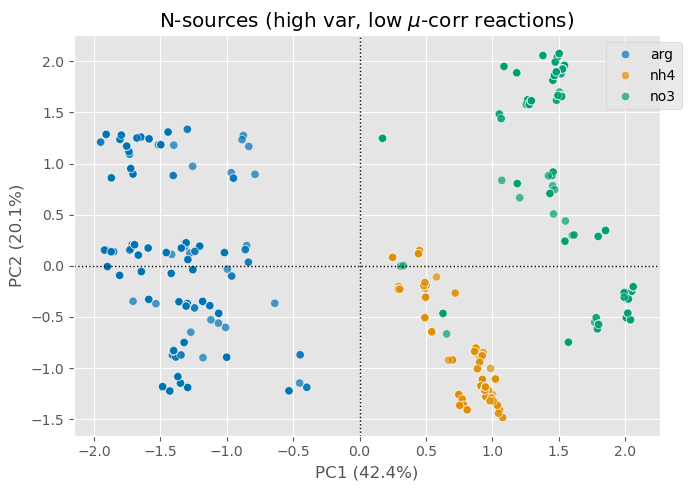

In [101]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df_pca_n,
    x="PC1",
    y="PC2",
    hue="source",
    palette="colorblind",
    alpha=0.7
)

plt.axhline(y=0, ls=":", c="k", lw=1)
plt.axvline(x=0, ls=":", c="k", lw=1)
plt.title(r"N-sources (high var, low $\mu$-corr reactions)")
plt.xlabel(f"PC1 ({pca_n.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca_n.explained_variance_ratio_[1]*100:.1f}%)")

plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

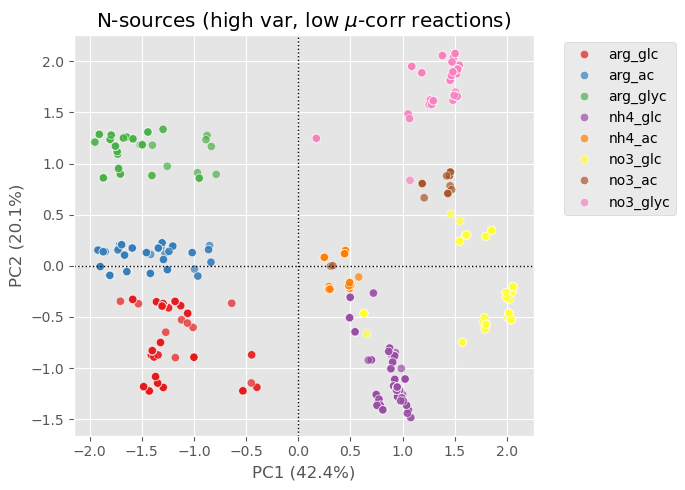

In [65]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df_pca_n,
    x="PC1",
    y="PC2",
    hue="source",
    palette="Set1",
    alpha=0.7
)

plt.axhline(y=0, ls=":", c="k", lw=1)
plt.axvline(x=0, ls=":", c="k", lw=1)
plt.title(r"N-sources (high var, low $\mu$-corr reactions)")
plt.xlabel(f"PC1 ({pca_n.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca_n.explained_variance_ratio_[1]*100:.1f}%)")

plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

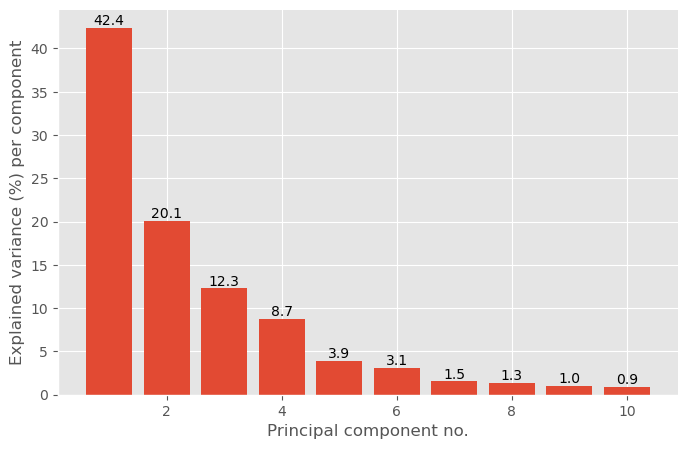

In [108]:
variance_n = pca_n.explained_variance_ratio_
components_n = 1 + np.arange(len(variance_n))

plt.figure(figsize=(8,5))
bar = plt.bar(components_n, variance_n*100)
plt.bar_label(bar, fmt="{:.1f}")
plt.xlabel('Principal component no.')
plt.ylabel('Explained variance (%) per component')
sns.despine()

In [75]:
loadings_n.sort_values(by='PC2', ascending=False)

,PC1,PC2,PC3
reaction,,,
translation_b3926,-3.076234e-02,0.383132,1.299865e-02
translation_b3946,-3.102709e-02,0.382552,1.317879e-02
translation_b3945,-3.102709e-02,0.382552,1.317879e-02
translation_b2203,2.338155e-01,0.179783,2.488188e-01
translation_b2206,2.338155e-01,0.179783,2.488188e-01
translation_b2202,2.338155e-01,0.179783,2.488188e-01
formation_NAPAB-CPLX_NAPC-MONOMER_mod_bmocogdp,2.310295e-01,0.177354,2.468248e-01
translation_b0963,2.649360e-02,0.066591,1.916369e-03
translation_b1778,1.283703e-02,0.051080,2.146535e-01


## Interesting reactions vs uptake etc.:

**CueO, nhd, formation_NADH-DHII-MONOMER_mod_mg2_mod_cu_mod_fad**

In [78]:
activity_fraction

,reaction,biomass_type,glc,ac,lcts,glyc,succ,arg_glc,arg_ac,arg_glyc,nh4_glc,nh4_ac,no3_glc,no3_ac,no3_glyc
1593,b1677_lipid_modification_pg181_p_pe160,lipid,0.000000,0.000000,0.000000,0.000000,0.000000,0.013493,0.012007,0.006126,0.040876,0.072165,0.031930,0.030303,0.038591
1599,b1677_lipid_modification_pg180_p_pe160,lipid,0.012802,0.087137,0.002545,0.015517,0.017682,0.002999,0.087479,0.006126,0.024818,0.144330,0.018868,0.000000,0.020134
1749,translation_b0123,protein,0.731152,0.319502,0.763359,0.594828,0.253438,0.578711,0.000000,0.486983,0.684672,0.000000,0.589260,0.000000,0.406040
1951,translation_b0720,protein,1.000000,1.000000,1.000000,1.000000,1.000000,0.902549,0.849057,0.885145,1.000000,1.000000,1.000000,1.000000,1.000000
1952,translation_b0721,protein,0.806543,1.000000,1.000000,0.796552,1.000000,0.998501,1.000000,0.998469,0.931387,1.000000,1.000000,1.000000,1.000000
1953,translation_b0722,protein,0.806543,1.000000,1.000000,0.796552,1.000000,0.998501,1.000000,0.998469,0.931387,1.000000,1.000000,1.000000,1.000000
1954,translation_b0723,protein,0.806543,1.000000,1.000000,0.796552,1.000000,0.998501,1.000000,0.998469,0.931387,1.000000,1.000000,1.000000,1.000000
1955,translation_b0724,protein,0.806543,1.000000,1.000000,0.796552,1.000000,0.998501,1.000000,0.998469,0.931387,1.000000,1.000000,1.000000,1.000000
1958,translation_b0728,protein,0.934566,1.000000,1.000000,0.970690,1.000000,1.000000,0.950257,0.998469,0.994161,1.000000,1.000000,1.000000,1.000000
1959,translation_b0729,protein,0.934566,1.000000,1.000000,0.970690,1.000000,1.000000,0.950257,0.998469,0.994161,1.000000,1.000000,1.000000,1.000000


In [101]:
active_ndh = activity_binary.columns[activity_binary.loc["translation_b1109"] == 1]

oxygen = df_clean[df_clean['reaction']=='EX_o2_e']
cueO = df_clean[df_clean['reaction']=='translation_b0123']
nadh_d2 = df_clean[df_clean['reaction']=='formation_NADH-DHII-MONOMER_mod_mg2_mod_cu_mod_fad']
cu = df_clean[df_clean['reaction']=='EX_cu2_e']
ndh = df_clean[df_clean['reaction']=='translation_b1109']

In [73]:
cols_drop = ['biomass_type', 'reaction']

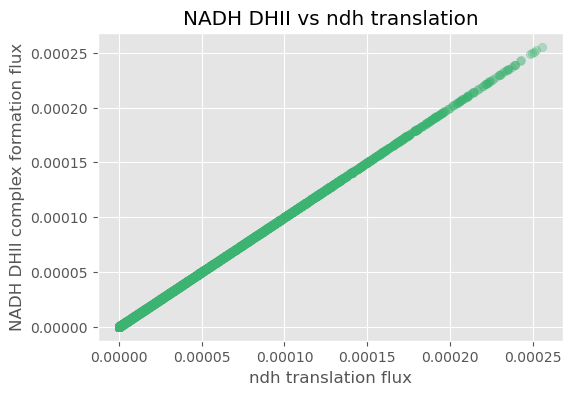

In [199]:
plt.figure(figsize=(6,4))
plt.scatter(ndh.drop(columns=cols_drop), nadh_d2.drop(columns=cols_drop),alpha=0.3, color='mediumseagreen')
plt.xlabel("ndh translation flux")
plt.ylabel("NADH DHII complex formation flux")
plt.title("NADH DHII vs ndh translation")
plt.show()

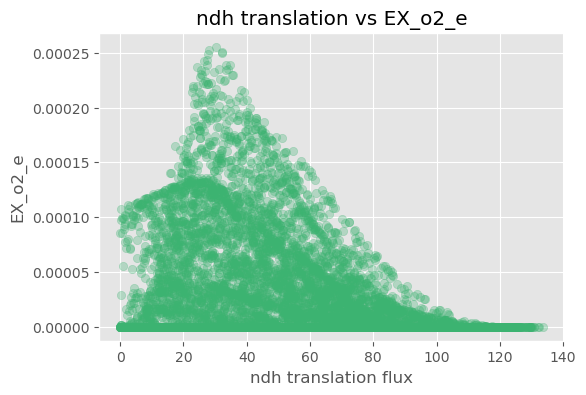

In [200]:
plt.figure(figsize=(6,4))
plt.scatter(-oxygen.drop(columns=cols_drop),ndh.drop(columns=cols_drop), alpha=0.3, color='mediumseagreen')
plt.xlabel("ndh translation flux")
plt.ylabel("EX_o2_e")
plt.title("ndh translation vs EX_o2_e")
plt.show()

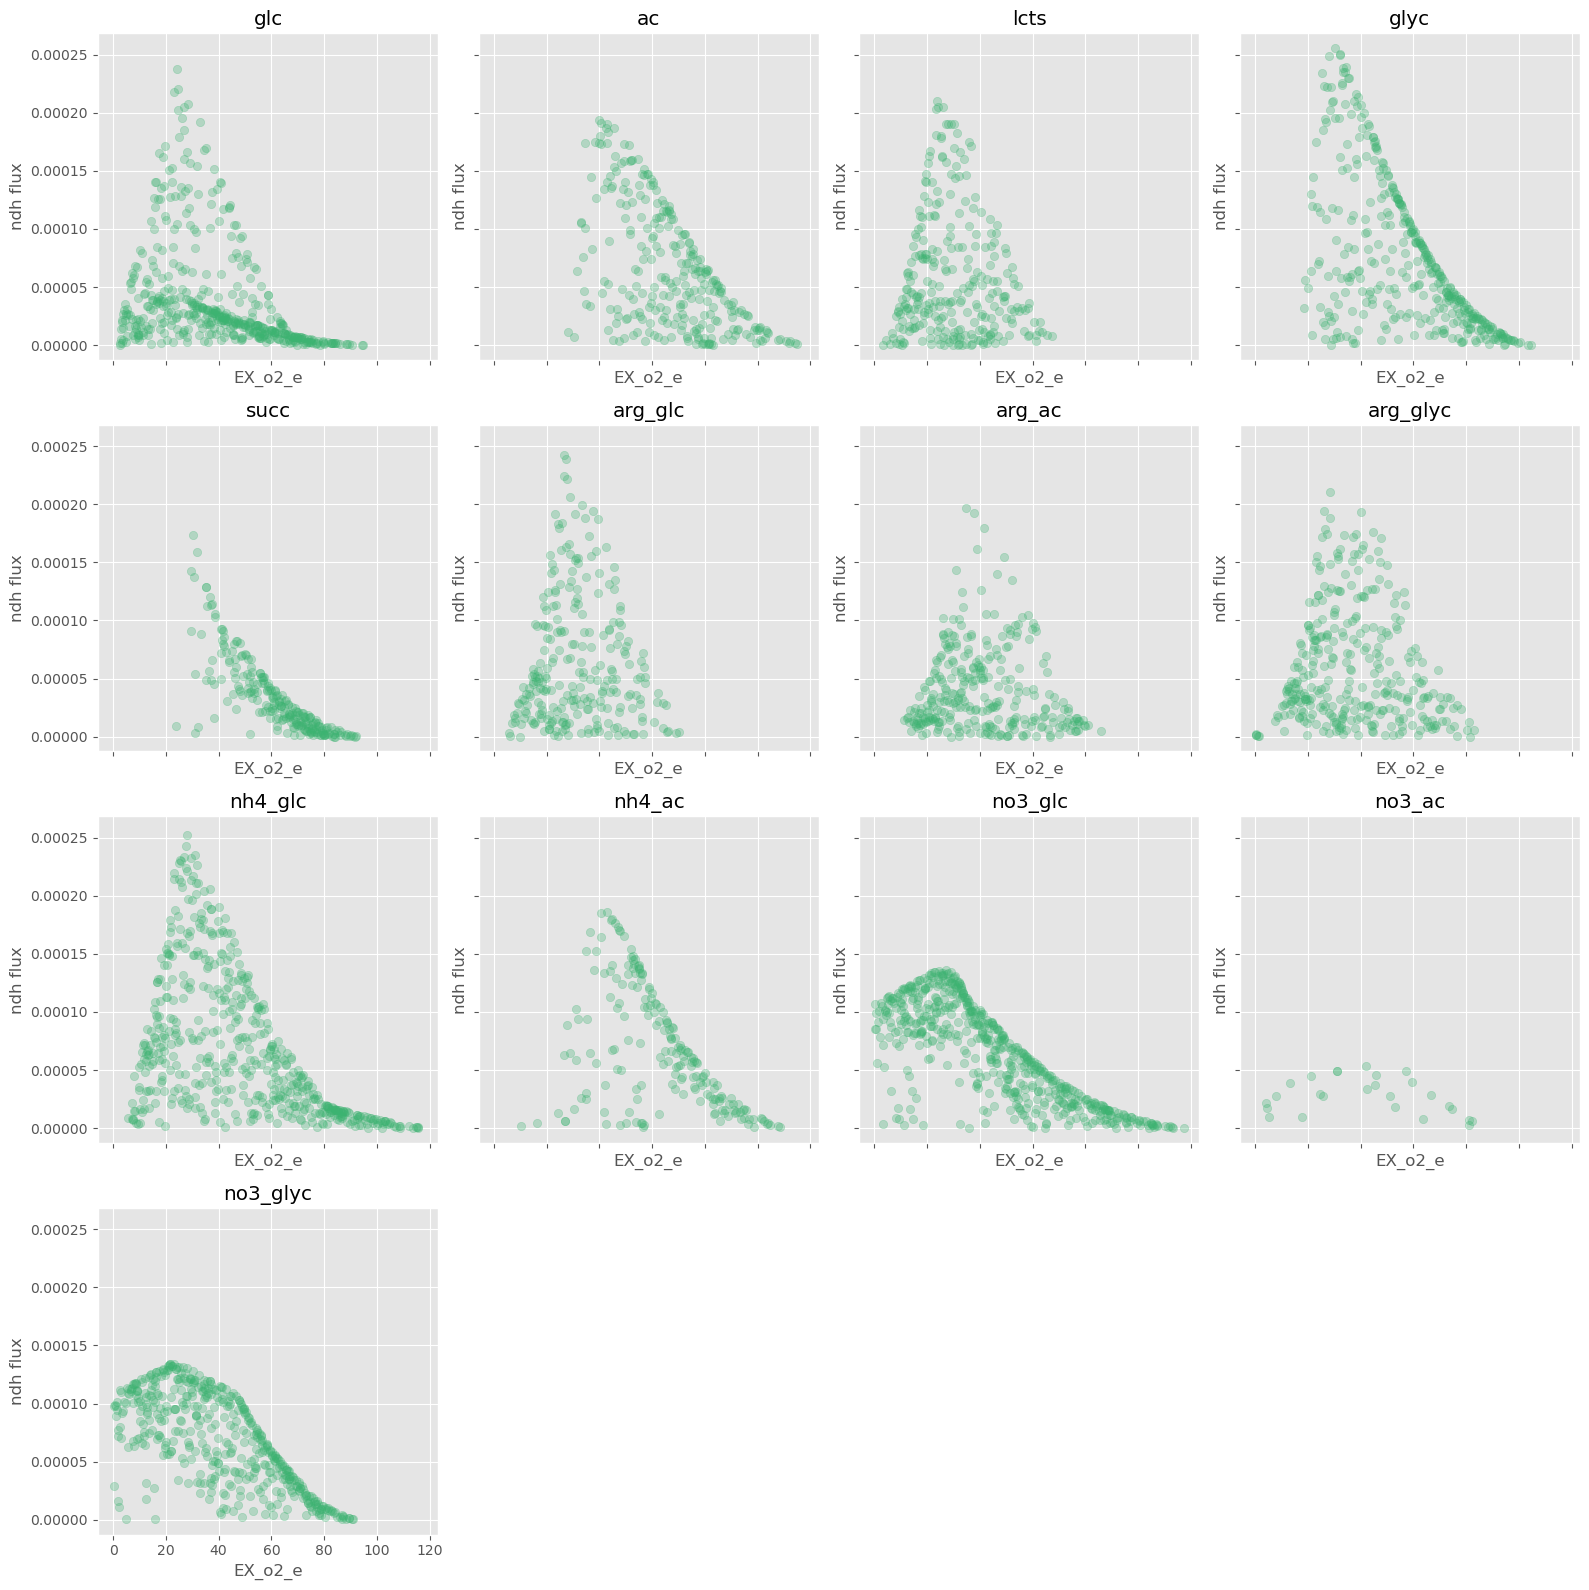

In [201]:
x = -oxygen.iloc[0][active_ndh]
y = ndh.iloc[0][active_ndh]

groups = x.index.to_series().str.split("_sample_").str[0]
envs = groups.unique()

ncols = 4
nrows = math.ceil(len(envs) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows), sharex=True, sharey=True)
axes = axes.flatten()

for i, env in enumerate(envs):
    ax = axes[i]
    cols = groups[groups == env].index

    ax.scatter(x[cols], y[cols], alpha=0.3, color='mediumseagreen')
    ax.set_title(env)
    ax.set_xlabel("EX_o2_e")
    ax.set_ylabel("ndh flux")

for j in range(len(envs), len(axes)):
    axes[j].set_visible(False)

# fig.suptitle("ndh vs oxygen uptake by environment")
fig.tight_layout()
plt.show()

**fsaB and gldA vs glucose uptake**

In [136]:
glc_rxn = df_clean[df_clean["reaction"] == "EX_glc__D_e"]
glc_active = glc_rxn.loc[:, glc_rxn.columns.str.startswith("glc_sample")].columns.tolist()

In [130]:
glc = df_clean[df_clean['reaction']=='EX_glc__D_e']
fsaB = df_clean[df_clean['reaction']=='translation_b3946']
gldA = df_clean[df_clean['reaction']=='translation_b3945']

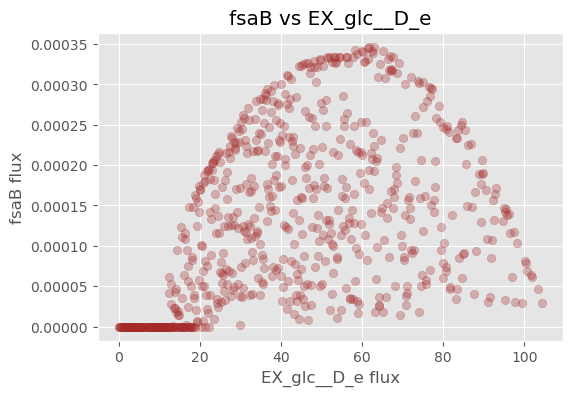

In [144]:
plt.figure(figsize=(6,4))
plt.scatter(-glc[glc_active], fsaB[glc_active],alpha=0.3, color='brown')
plt.xlabel("EX_glc__D_e flux")
plt.ylabel("fsaB flux")
plt.title("fsaB vs EX_glc__D_e")
plt.show()

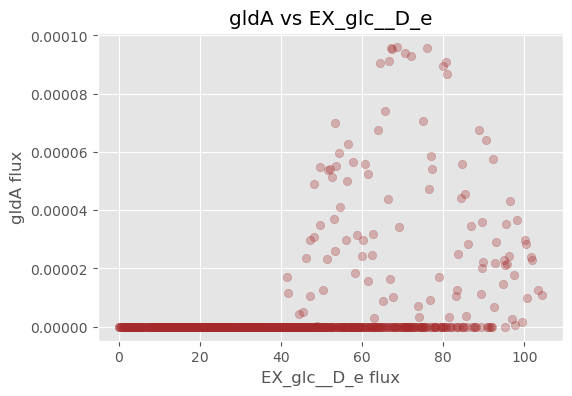

In [145]:
plt.figure(figsize=(6,4))
plt.scatter(-glc[glc_active], gldA[glc_active],alpha=0.3, color='brown')
plt.xlabel("EX_glc__D_e flux")
plt.ylabel("gldA flux")
plt.title("gldA vs EX_glc__D_e")
plt.show()

**decarboxylase vs arginine uptake**

In [150]:
arg_rxn = df_clean[df_clean["reaction"] == "EX_arg__L_e"]
arg_active = arg_rxn.loc[:, arg_rxn.columns.str.startswith("arg_")].columns.tolist()

In [178]:
arg = df_clean[df_clean['reaction']=='EX_arg__L_e']
argdec = df_clean[df_clean['reaction']=='formation_ARGDECARBOXBIO-CPLX_mod_mg2_mod_4:pydx5p']
adi = df_clean[df_clean['reaction']=='translation_b4117']

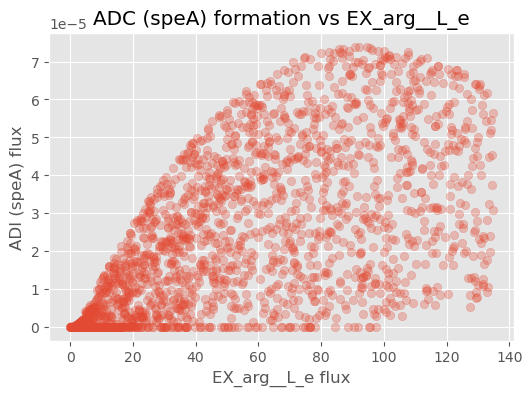

In [203]:
plt.figure(figsize=(6,4))
plt.scatter(-arg[arg_active], argdec[arg_active],alpha=0.3)
plt.xlabel("EX_arg__L_e flux")
plt.ylabel("ADI (speA) flux")
plt.title("ADC (speA) formation vs EX_arg__L_e")
plt.show()

In [189]:
active_speA = activity_binary.columns[activity_binary.loc["translation_b2938"] == 1]

speA = df_clean[df_clean['reaction']=='translation_b2938']

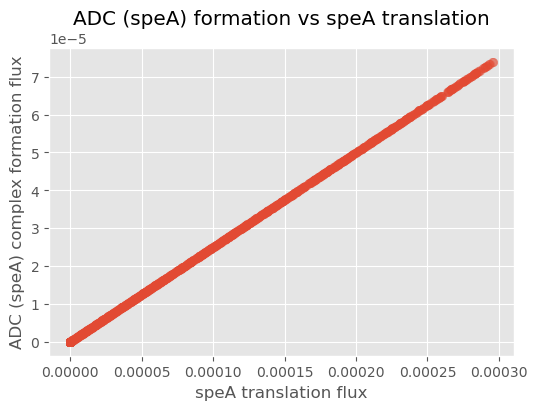

In [204]:
plt.figure(figsize=(6,4))
plt.scatter(speA.drop(columns=cols_drop), argdec.drop(columns=cols_drop),alpha=0.3)
plt.xlabel("speA translation flux")
plt.ylabel("ADC (speA) complex formation flux")
plt.title("ADC (speA) formation vs speA translation")
plt.show()

**Succinate dehydrogenase**

In [182]:
sdh_rxn = df_clean[df_clean["reaction"] == "translation_b0721"]
sdh_active = activity_binary.columns[activity_binary.loc["translation_b0721"] == 1]

sdh = df_clean[df_clean['reaction']=='formation_SUCC-DEHASE_mod_3fe4s_mod_fad_mod_2fe2s_mod_4fe4s']

* **SDH vs oxygen in glc and glyc -> only synthesized in aerobic conditions here?**
    * no, but substrate is limiting

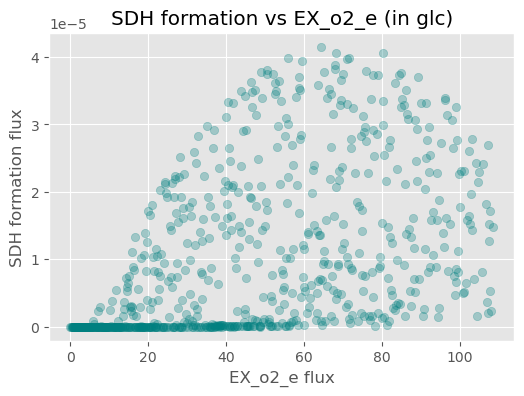

In [205]:
plt.figure(figsize=(6,4))
plt.scatter(-oxygen[glc_active], sdh[glc_active],alpha=0.3, color='teal')
plt.xlabel("EX_o2_e flux")
plt.ylabel("SDH formation flux")
plt.title("SDH formation vs EX_o2_e (in glc)")
plt.show()

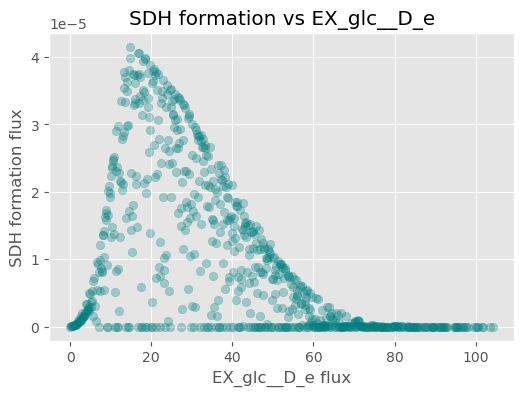

In [206]:
plt.figure(figsize=(6,4))
plt.scatter(-glc[glc_active], sdh[glc_active],alpha=0.3, color='teal')
plt.xlabel("EX_glc__D_e flux")
plt.ylabel("SDH formation flux")
plt.title("SDH formation vs EX_glc__D_e")
plt.show()

In [174]:
glyc_rxn = df_clean[df_clean["reaction"] == "EX_glyc_e"]
glyc_active = glyc_rxn.loc[:, glyc_rxn.columns.str.startswith("glyc_sample")].columns.tolist()

glyc = df_clean[df_clean['reaction']=='EX_glyc_e']

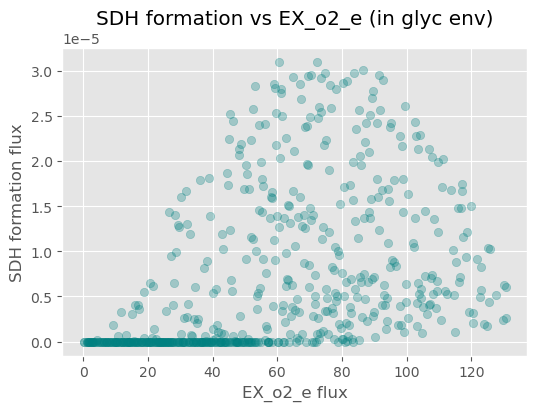

In [207]:
plt.figure(figsize=(6,4))
plt.scatter(-oxygen[glyc_active], sdh[glyc_active],alpha=0.3, color='teal')
plt.xlabel("EX_o2_e flux")
plt.ylabel("SDH formation flux")
plt.title("SDH formation vs EX_o2_e (in glyc env)")
plt.show()

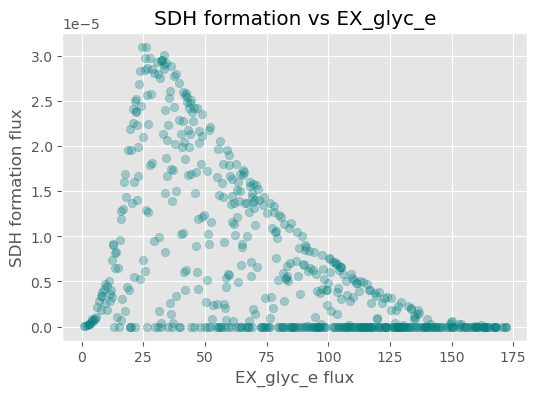

In [208]:
plt.figure(figsize=(6,4))
plt.scatter(-glyc[glyc_active], sdh[glyc_active],alpha=0.3, color='teal')
plt.xlabel("EX_glyc_e flux")
plt.ylabel("SDH formation flux")
plt.title("SDH formation vs EX_glyc_e")
plt.show()

* **SDH subunits translation vs SDH formation**

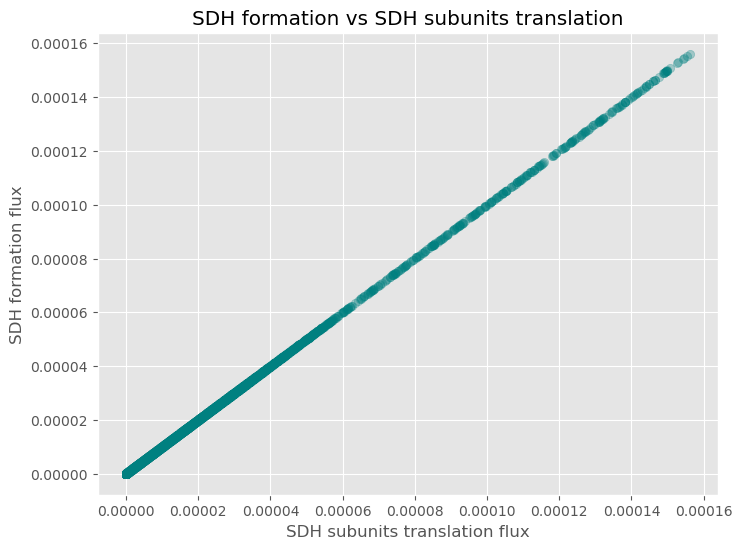

In [209]:
plt.figure(figsize=(8,6))
plt.scatter(sdh_rxn.drop(columns=cols_drop), sdh.drop(columns=cols_drop),alpha=0.3, color='teal')
plt.xlabel("SDH subunits translation flux")
plt.ylabel("SDH formation flux")
plt.title("SDH formation vs SDH subunits translation")
plt.show()

**NapAB complex vs napA-C and nitrate**

In [210]:
no3_rxn = df_clean[df_clean["reaction"] == "EX_no3_e"]
no3_active = no3_rxn.loc[:, no3_rxn.columns.str.startswith("no3_")].columns.tolist()

no3 = df_clean[df_clean['reaction']=='EX_no3_e']

In [214]:
napA_rxn = df_clean[df_clean["reaction"] == "translation_b2206"]
napAB = df_clean[df_clean['reaction']=='formation_NAPAB-CPLX_NAPC-MONOMER_mod_bmocogdp']

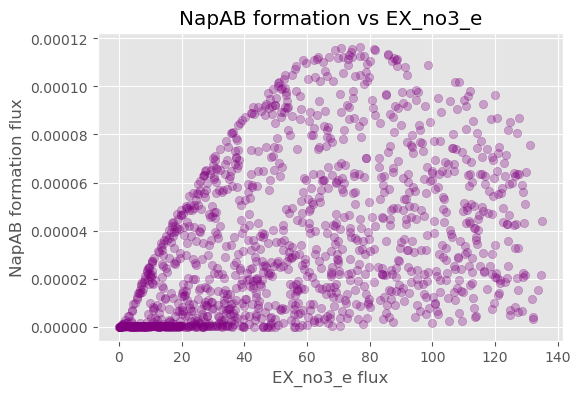

In [215]:
plt.figure(figsize=(6,4))
plt.scatter(-no3[no3_active], napAB[no3_active],alpha=0.3, color='purple')
plt.xlabel("EX_no3_e flux")
plt.ylabel("NapAB formation flux")
plt.title("NapAB formation vs EX_no3_e")
plt.show()

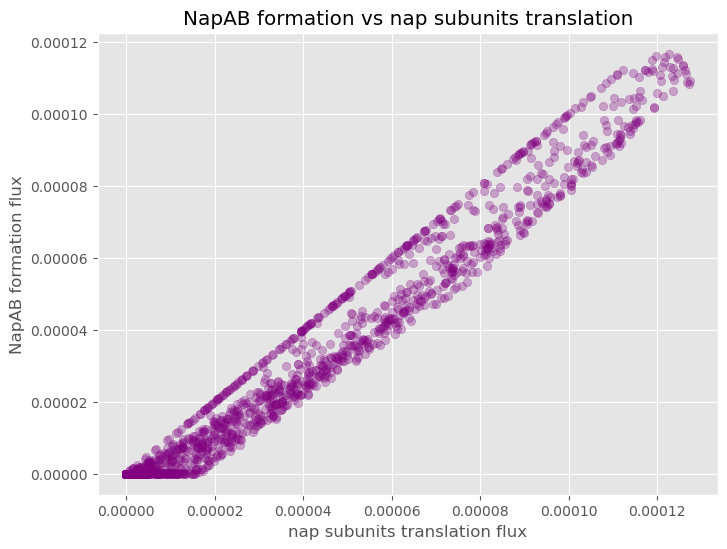

In [220]:
plt.figure(figsize=(8,6))
plt.scatter(napA_rxn.drop(columns=cols_drop), napAB.drop(columns=cols_drop),alpha=0.3, color='purple')
plt.xlabel("nap subunits translation flux")
plt.ylabel("NapAB formation flux")
plt.title("NapAB formation vs nap subunits translation")
plt.show()

```text
translation_b2202
translation_b2203
translation_b2206


```text
de tre blir også transkribert sammen med:
'RNA_b2197', 'RNA_b2198', 'RNA_b2199', 'RNA_b2200', 
'RNA_b2201', 'RNA_b2202', 'RNA_b2203', 'RNA_b2204', 
'RNA_b2205',  'RNA_b2206', , 'RNA_b2207',  

ABC complex lager ikke prostetisk gruppe biomasse, men den trenger noen av de i TU'en som ikke brukes til NapAB
* poenget er at i dette tilfellet så vil transkripsjonen av de tre RNAene som blir til de tre proteinene, også påvirkes av andre proteiner som må lages